# Classical microstate parameters: duration, occurrence, and coverage

This notebook computes and visualises the three **classical EEG microstate parameters** from the MPILMBB dataset:

| Parameter | Symbol | Unit |
|-----------|--------|------|
| Mean duration | $\overline{d}_k$ | ms |
| Occurrence rate | $\lambda_k$ | events s$^{-1}$ |
| Coverage | $\rho_k$ | — (fraction) |

These are extracted with `mstsa.dur_occ_cov` for four smoothing conditions derived from the method of Pascual-Marqui et al. (1995). The smoothing **window half-size $b$** controls how many neighbouring samples contribute to each microstate assignment; larger $b$ produces smoother, longer-lasting microstates.  
Filenames containing `b1`, `b3`, and `b9` correspond to smoothing window half-sizes $b = 1, 3, 9$ samples. Total window widths are $2b+1 = 3, 7, 19$ samples, or 12 ms, 28 ms, 76 ms at 250 Hz sampling rate. The filename part `ip` denotes GFP peak interpolation, i.e. back-fitting only occurs at GFP peaks and all other time points are assigned to their closest GFP peak.

**Dataset:** MPILMBB eyes-closed resting-state EEG, $K = 4$ microstates, $f_s = 250$ Hz (4 ms / sample).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import mstsa

print(f"mstsa version: {mstsa.__version__}")

mstsa version: 0.4.2


## 1. Setup

In [2]:
data_path = Path("../data/mpilmbb")

fs = 250          # Hz  (4 ms per sample)
K  = 4            # number of microstates

conditions  = ['b1', 'b3', 'b9', 'ip']
cond_labels = {'b1': 'b = 1', 'b3': 'b = 3', 'b9': 'b = 9', 'ip': 'IP'}
ms_labels   = ['A', 'B', 'C', 'D']

subjects = sorted(set(f.name.split('_')[0] for f in data_path.glob("*.npy")))
print(f"{len(subjects)} subjects, {len(conditions)} conditions")

201 subjects, 4 conditions


## 2. Compute microstate parameters

`mstsa.dur_occ_cov(x, fs)` takes an integer microstate sequence `x` and the sampling rate `fs`,
and returns:

- `dur_dict` — a dict mapping each microstate index to the list of individual sojourn durations (ms);
- `occ` — occurrence rate array, shape `(K,)`, in events s$^{-1}$;
- `cov` — coverage array, shape `(K,)`, as a fraction of total recording time.

The first and last microstates are excluded by default because their durations are censored at the
recording boundaries.

In [3]:
results = {cond: {'dur': [], 'occ': [], 'cov': []} for cond in conditions}

for subj in subjects:
    for cond in conditions:
        fname = data_path / f"{subj}_EC_ms_{cond}_K4_ep00.npy"
        x = np.load(fname)
        dur_dict, occ, cov = mstsa.dur_occ_cov(x, fs=fs)
        mean_dur = np.array([np.mean(dur_dict[k]) for k in range(K)])
        results[cond]['dur'].append(mean_dur)
        results[cond]['occ'].append(occ)
        results[cond]['cov'].append(cov)

for cond in conditions:
    for key in ['dur', 'occ', 'cov']:
        results[cond][key] = np.array(results[cond][key])  # shape (n_subjects, K)
    print(f"{cond_labels[cond]:>6s}: {results[cond]['dur'].shape[0]} subjects")

 b = 1: 201 subjects
 b = 3: 201 subjects
 b = 9: 201 subjects
    IP: 201 subjects


## 3. Visualisation

Grouped box plots: one panel per measure, boxes grouped by **smoothing
condition** (`b1`, `b3`, `b9`, `ip`) on the x-axis, colours encoding
microstate class (A–D).

The factor of interest is smoothing, not microstate class. Since all four
smoothing conditions come from the *same* subjects, the effect of smoothing
is tested with a repeated-measures omnibus test per measure, pooled across
microstates (each subject's value is averaged over the K microstates first,
then compared across the four matched smoothing conditions): a Shapiro-Wilk
check decides between repeated-measures ANOVA (if every condition's pooled
distribution is normal) and the non-parametric Friedman test otherwise.

**Only if that omnibus test is significant**, pairwise post-hoc comparisons
between all six smoothing-condition pairs follow (paired t-test or Wilcoxon
signed-rank, matching the omnibus test, Holm-Bonferroni corrected across the
six comparisons). Brackets are drawn only for the pairs that remain
significant after correction, stacked so overlapping spans don't collide.

In [4]:
import pandas as pd
from itertools import combinations
from scipy.stats import shapiro, friedmanchisquare, wilcoxon, ttest_rel
from statsmodels.stats.anova import AnovaRM

measures     = ['dur', 'occ', 'cov']
ylabels      = ['Mean duration (ms)', 'Occurrence (events / s)', 'Coverage']
panel_titles = ['Duration', 'Occurrence', 'Coverage']

n_cond = len(conditions)
ms_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']  # one per microstate

box_width = 0.15
offsets   = np.linspace(-(K - 1) / 2, (K - 1) / 2, K) * box_width * 1.3
x_pos     = np.arange(n_cond)


def sig_stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def effect_label(w):
    if w < 0.1:
        return 'negligible'
    if w < 0.3:
        return 'small'
    if w < 0.5:
        return 'moderate'
    return 'large'


def compare_conditions(data_by_cond, use_parametric):
    """Repeated-measures omnibus test of the smoothing factor across the
    (matched) conditions in `data_by_cond` (dict cond -> (n_subjects,) array).
    Also reports an effect size: Kendall's W for Friedman (stat / (n*(k-1))),
    partial eta-squared for RM-ANOVA (F*df1 / (F*df1+df2)) -- both scaled 0-1,
    needed because with n=201 subjects even tiny, practically unimportant
    differences reach very small p-values."""
    n = len(next(iter(data_by_cond.values())))
    k = len(data_by_cond)
    if use_parametric:
        df = pd.DataFrame({
            'subject': np.tile(np.arange(n), k),
            'condition': np.repeat(list(data_by_cond.keys()), n),
            'value': np.concatenate(list(data_by_cond.values())),
        })
        aov = AnovaRM(df, 'value', 'subject', within=['condition']).fit()
        stat = aov.anova_table['F Value'].iloc[0]
        p = aov.anova_table['Pr > F'].iloc[0]
        df1 = aov.anova_table['Num DF'].iloc[0]
        df2 = aov.anova_table['Den DF'].iloc[0]
        effect = (stat * df1) / (stat * df1 + df2)
        test = 'RM-ANOVA'
    else:
        stat, p = friedmanchisquare(*data_by_cond.values())
        effect = stat / (n * (k - 1))  # Kendall's W
        test = 'Friedman'
    return dict(test=test, statistic=stat, pvalue=p, effect=effect)


def holm_correct(pvals):
    """Holm-Bonferroni step-down correction. Returns adjusted p-values in the
    original order of `pvals`."""
    m = len(pvals)
    order = np.argsort(pvals)
    adjusted = np.empty(m)
    running_max = 0.0
    for rank, idx in enumerate(order):
        running_max = max(running_max, (m - rank) * pvals[idx])
        adjusted[idx] = min(running_max, 1.0)
    return adjusted


def pairwise_posthoc(data_by_cond, use_parametric):
    """Pairwise post-hoc tests between all condition pairs (paired t-test if
    the omnibus used RM-ANOVA, Wilcoxon signed-rank if it used Friedman),
    Holm-corrected across all pairs. Returns list of dicts, one per pair,
    each with cond1, cond2, pvalue (corrected)."""
    conds = list(data_by_cond.keys())
    pairs = list(combinations(conds, 2))
    raw_p = []
    for c1, c2 in pairs:
        if use_parametric:
            _, p = ttest_rel(data_by_cond[c1], data_by_cond[c2])
        else:
            _, p = wilcoxon(data_by_cond[c1], data_by_cond[c2])
        raw_p.append(p)
    adj_p = holm_correct(np.array(raw_p))
    return [dict(cond1=c1, cond2=c2, pvalue=p)
            for (c1, c2), p in zip(pairs, adj_p)]


alpha = 0.05
stats_results = {}
for measure in measures:
    # Factor of interest is smoothing (b1/b3/b9/IP), not microstate class:
    # average each subject's value over the K microstates first, then test
    # the smoothing factor once per measure -- a single pooled test, not one
    # per microstate.
    pooled_by_cond = {cond: results[cond][measure].mean(axis=1) for cond in conditions}

    normal_measure = all(
        shapiro(pooled_by_cond[cond]).pvalue > alpha for cond in conditions
    )
    test_name = 'RM-ANOVA' if normal_measure else 'Friedman'
    print(f"{measure}: {'all normal' if normal_measure else 'at least one non-normal'} "
          f"-> using {test_name}")

    res = compare_conditions(pooled_by_cond, normal_measure)
    print(f"  smoothing effect: {res['test']:>9s}  stat={res['statistic']:.3f}  "
          f"p={res['pvalue']:.4g}  {sig_stars(res['pvalue'])}   "
          f"effect={res['effect']:.3f} ({effect_label(res['effect'])})")

    # pairwise post-hoc only runs if the omnibus test is itself significant
    if res['pvalue'] < alpha:
        res['posthoc'] = pairwise_posthoc(pooled_by_cond, normal_measure)
        for ph in res['posthoc']:
            print(f"    {ph['cond1']} vs {ph['cond2']}: p={ph['pvalue']:.4g} "
                  f"{sig_stars(ph['pvalue'])} (Holm-corrected)")
    else:
        res['posthoc'] = None
        print("    omnibus not significant -> no pairwise post-hoc run")

    stats_results[measure] = res

dur: at least one non-normal -> using Friedman
  smoothing effect:  Friedman  stat=600.624  p=7.381e-130  ***   effect=0.996 (large)
    b1 vs b3: p=5.908e-34 *** (Holm-corrected)
    b1 vs b9: p=5.908e-34 *** (Holm-corrected)
    b1 vs ip: p=5.908e-34 *** (Holm-corrected)
    b3 vs b9: p=5.908e-34 *** (Holm-corrected)
    b3 vs ip: p=5.908e-34 *** (Holm-corrected)
    b9 vs ip: p=5.908e-34 *** (Holm-corrected)
occ: at least one non-normal -> using Friedman
  smoothing effect:  Friedman  stat=600.624  p=7.381e-130  ***   effect=0.996 (large)
    b1 vs b3: p=5.908e-34 *** (Holm-corrected)
    b1 vs b9: p=5.908e-34 *** (Holm-corrected)
    b1 vs ip: p=5.908e-34 *** (Holm-corrected)
    b3 vs b9: p=5.908e-34 *** (Holm-corrected)
    b3 vs ip: p=5.908e-34 *** (Holm-corrected)
    b9 vs ip: p=5.908e-34 *** (Holm-corrected)
cov: at least one non-normal -> using Friedman
  smoothing effect:  Friedman  stat=5.741  p=0.1249  ns   effect=0.010 (negligible)
    omnibus not significant -> no pairw

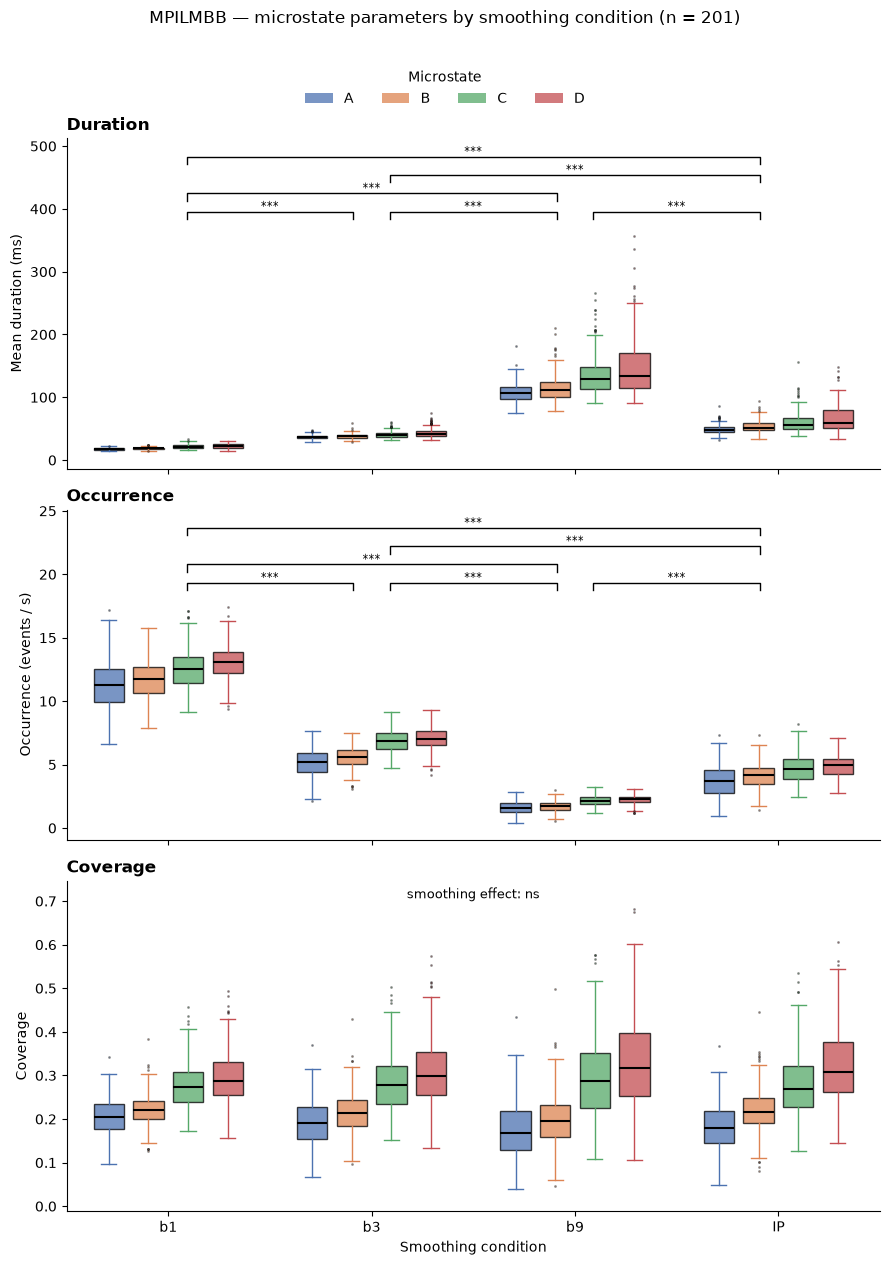

In [5]:
def add_sig_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.0, c='k')
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=8)


def stack_tiers(spans):
    """Assign each (x1, x2) span a vertical tier (0, 1, 2, ...) such that
    spans sharing a tier never overlap in x. Greedy, shortest spans first,
    so adjacent-pair brackets sit lowest and the widest bracket sits highest."""
    order = sorted(range(len(spans)), key=lambda i: spans[i][1] - spans[i][0])
    tiers = []  # list of lists of (x1, x2) already placed in that tier
    tier_of = [None] * len(spans)
    for i in order:
        x1, x2 = spans[i]
        for ti, tier in enumerate(tiers):
            if all(x2 <= t1 or x1 >= t2 for (t1, t2) in tier):
                tier.append((x1, x2))
                tier_of[i] = ti
                break
        else:
            tiers.append([(x1, x2)])
            tier_of[i] = len(tiers) - 1
    return tier_of, len(tiers)


cond_to_x = {cond: x_pos[ci] for ci, cond in enumerate(conditions)}
bracket_inset = 0.09  # shrink each bracket's span inward so touching ticks don't merge

fig, axes = plt.subplots(3, 1, figsize=(9, 12), sharex=True)

for row, (measure, ylabel, title) in enumerate(zip(measures, ylabels, panel_titles)):
    ax = axes[row]
    for k in range(K):
        data_k = np.array([results[cond][measure][:, k] for cond in conditions]).T  # (n_subjects, n_cond)
        bp = ax.boxplot(
            [data_k[:, ci] for ci in range(n_cond)],
            positions   = x_pos + offsets[k],
            widths      = box_width,
            patch_artist= True,
            boxprops    = dict(facecolor=ms_colors[k], alpha=0.75),
            medianprops = dict(color='black', linewidth=1.5),
            whiskerprops= dict(color=ms_colors[k]),
            capprops    = dict(color=ms_colors[k]),
            flierprops  = dict(marker='.', markersize=2, alpha=0.4,
                               markerfacecolor=ms_colors[k]),
        )

    # pairwise post-hoc brackets (only pairs significant after Holm
    # correction; only present at all if the omnibus test was significant)
    all_vals = np.concatenate([results[cond][measure] for cond in conditions])  # (n_subj*4, K)
    ymax, ymin = all_vals.max(), all_vals.min()
    span = ymax - ymin
    bracket_h = 0.035 * span
    gap = 0.05 * span
    base_y = ymax + 0.08 * span

    res = stats_results[measure]
    sig_pairs = [ph for ph in (res['posthoc'] or []) if ph['pvalue'] < alpha]

    if sig_pairs:
        # tiers are computed on the true (uninset) spans, so overlap detection
        # still reflects the real comparison width
        true_spans = [(cond_to_x[ph['cond1']], cond_to_x[ph['cond2']]) for ph in sig_pairs]
        tier_of, n_tiers = stack_tiers(true_spans)
        for (x1, x2), tier, ph in zip(true_spans, tier_of, sig_pairs):
            y = base_y + tier * (bracket_h + gap)
            add_sig_bracket(ax, x1 + bracket_inset, x2 - bracket_inset,
                             y, bracket_h, sig_stars(ph['pvalue']))
        ax.set_ylim(ymin - 0.08 * span, base_y + n_tiers * (bracket_h + gap) + bracket_h)
    else:
        ax.text(0.5, 0.98, f"smoothing effect: {sig_stars(res['pvalue'])}",
                 transform=ax.transAxes, ha='center', va='top', fontsize=9)
        ax.set_ylim(ymin - 0.08 * span, ymax + 0.1 * span)

    ax.set_xlim(-0.5, n_cond - 0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xticks(x_pos)
axes[-1].set_xticklabels(['b1', 'b3', 'b9', 'IP'])
axes[-1].set_xlabel('Smoothing condition')

legend_handles = [
    mpatches.Patch(facecolor=ms_colors[k], alpha=0.75, label=ms_labels[k])
    for k in range(K)
]

fig.suptitle(
    f'MPILMBB — microstate parameters by smoothing condition (n = {len(subjects)})',
    fontsize=12, y=1.05
)
fig.legend(handles=legend_handles, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, 1.01), frameon=False, title='Microstate')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/00_microstate_parameters.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Group-level summary

Mean ± SD across subjects, per microstate and condition.

In [6]:
for measure, ylabel in zip(measures, ylabels):
    print(f"\n{ylabel}")
    print(f"{'Condition':>10s}  " + "  ".join(f"MS {l:>6s}" for l in ms_labels))
    print("-" * 60)
    for cond in conditions:
        data = results[cond][measure]   # (n_subjects, K)
        m = data.mean(axis=0)
        s = data.std(axis=0)
        row_str = "  ".join(f"{m[k]:6.2f}±{s[k]:.2f}" for k in range(K))
        print(f"{cond_labels[cond]:>10s}  {row_str}")


Mean duration (ms)
 Condition  MS      A  MS      B  MS      C  MS      D
------------------------------------------------------------
     b = 1   17.91±1.81   18.79±1.94   21.96±2.94   22.60±3.44
     b = 3   36.97±3.31   38.25±3.87   40.85±5.07   43.34±6.97
     b = 9  108.30±15.41  114.42±20.73  135.18±32.44  148.58±47.76
        IP   49.19±7.06   54.37±10.24   60.60±16.26   66.72±21.49

Occurrence (events / s)
 Condition  MS      A  MS      B  MS      C  MS      D
------------------------------------------------------------
     b = 1   11.35±1.86   11.74±1.43   12.61±1.57   13.06±1.34
     b = 3    5.11±1.14    5.58±0.83    6.85±0.90    7.05±0.86
     b = 9    1.59±0.52    1.73±0.43    2.16±0.44    2.24±0.37
        IP    3.75±1.24    4.11±1.01    4.68±1.05    4.93±0.83

Coverage
 Condition  MS      A  MS      B  MS      C  MS      D
------------------------------------------------------------
     b = 1    0.20±0.05    0.22±0.04    0.28±0.05    0.30±0.06
     b = 3    0.19±0.06

## 5. Duration and occurrence are not independent 

The three classical parameters are not independent measurements. By definition, 
coverage is the fraction of total recording time spent in a microstate, which is 
exactly **occurrence × mean duration**. In theory, reporting two of them would 
be sufficient.

Since coverage was essentially unaffected by smoothing, we can expect a hyperbolic 
relationship between duration and occurrence across smoothing methods: 
$\text{occurrence}\propto 1/\text{duration}$. This should result in a straight 
line with slope $-1$ in log-log axes.

In [7]:
from scipy.stats import pearsonr, linregress

product_all, cov_all, dur_sec_all, occ_all = [], [], [], []
for cond in conditions:
    dur_sec = results[cond]['dur'] / 1000.0  # ms -> s
    occ = results[cond]['occ']
    product = dur_sec * occ  # (n_subjects, K)
    cov = results[cond]['cov']

    rel_err = np.abs(product - cov) / cov
    print(f"{cond_labels[cond]:>10s}: mean relative deviation "
          f"|duration×occurrence - coverage| / coverage = {rel_err.mean():.4f}")

    product_all.append(product.ravel())
    cov_all.append(cov.ravel())
    dur_sec_all.append(dur_sec.ravel())
    occ_all.append(occ.ravel())

product_all = np.concatenate(product_all)
cov_all = np.concatenate(cov_all)
dur_sec_all = np.concatenate(dur_sec_all)
occ_all = np.concatenate(occ_all)

r, p = pearsonr(product_all, cov_all)
print(f"\nduration×occurrence vs. coverage (all conditions, all microstates, "
      f"n={len(product_all)}): Pearson r = {r:.5f}, p = {p:.3g}")

slope, intercept, r_loglog, p_loglog, se = linregress(np.log(dur_sec_all), np.log(occ_all))
print(f"\nlog(occurrence) ~ slope * log(duration): slope = {slope:.4f} "
      f"(expect -1 for an exact hyperbola), R^2 = {r_loglog**2:.5f}")

     b = 1: mean relative deviation |duration×occurrence - coverage| / coverage = 0.0000
     b = 3: mean relative deviation |duration×occurrence - coverage| / coverage = 0.0000
     b = 9: mean relative deviation |duration×occurrence - coverage| / coverage = 0.0000
        IP: mean relative deviation |duration×occurrence - coverage| / coverage = 0.0000

duration×occurrence vs. coverage (all conditions, all microstates, n=3216): Pearson r = 1.00000, p = 0

log(occurrence) ~ slope * log(duration): slope = -0.9217 (expect -1 for an exact hyperbola), R^2 = 0.75565


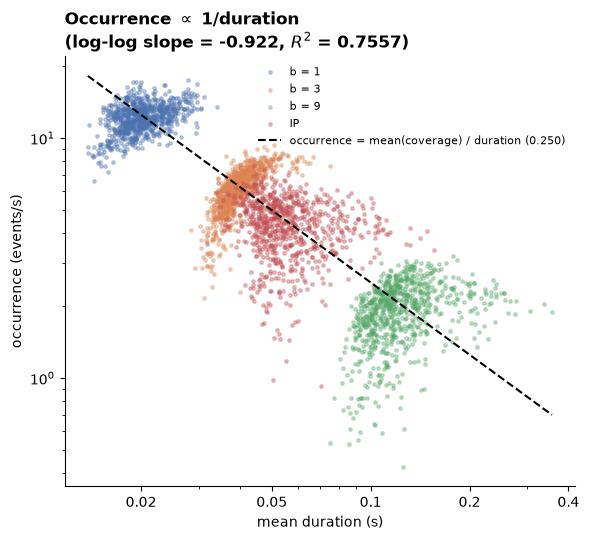

In [8]:
cond_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']  # one per smoothing condition

fig, ax = plt.subplots(figsize=(6, 5.5))
for ci, cond in enumerate(conditions):
    dur_sec = results[cond]['dur'].ravel() / 1000.0
    occ = results[cond]['occ'].ravel()
    ax.scatter(dur_sec, occ, s=6, alpha=0.35, color=cond_colors[ci],
               label=cond_labels[cond])

mean_cov = cov_all.mean()
dur_range = np.linspace(dur_sec_all.min(), dur_sec_all.max(), 200)
ax.plot(dur_range, mean_cov / dur_range, 'k--', lw=1.5,
        label=f'occurrence = mean(coverage) / duration ({mean_cov:.3f})')

ax.set_xscale('log')
ax.set_yscale('log')
xticks = [0.02, 0.05, 0.1, 0.2, 0.4]
ax.set_xticks(xticks)
ax.set_xticklabels([f'{t:g}' for t in xticks])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xlabel('mean duration (s)')
ax.set_ylabel('occurrence (events/s)')
ax.set_title(f'Occurrence $\\propto$ 1/duration\n'
             f'(log-log slope = {slope:.3f}, $R^2$ = {r_loglog**2:.4f})',
             loc='left', fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/00_duration_occurrence_hyperbolic.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conclusions

1. Smoothing has a strong impact on classical microstate parameters duration and occurrence, increasing durations and decreasing occurrence
2. Coverage is not affected by smoothing
3. Duration and occurrence _change continuously_ with smoothing strength. Thus, durations are _tunable_ parameters and, strictly speaking, can only be compared across studies when these studies used at least similar preprocessing parameters. Similar effects occur with other microstate metrics as well. In this notebook, mean durations changed more than five-fold, using smoothing parameters that can be found in the literature.
4. Duration, occurrence, and coverage are not independent measurements.